In [38]:
import pandas as pd
import numpy as np

test_data = pd.DataFrame({
    "month": ["January", "February", "March"],
    "demand": [100, 120, 115]
})

print("Jupyter works!")
test_data

Jupyter works!


,month,demand
0,January,100
1,February,120
2,March,115


In [39]:
import sys
import pandas as pd
import numpy as np

print(sys.executable)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

c:\Users\sasha\Projects\supply-chain-demand-forecast\.venv\Scripts\python.exe
Pandas version: 3.0.5
NumPy version: 2.5.2


In [40]:
import os
from pathlib import Path

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Находим .env в корне проекта
env_path = Path.cwd() / ".env"

if not env_path.exists():
    env_path = Path.cwd().parent / ".env"

load_dotenv(env_path)

# Собираем адрес подключения без публикации пароля
database_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(database_url)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    ).one()

    print("Database:", result[0])
    print("User:", result[1])
    print("Python → PostgreSQL connection works!")

Database: supply_chain_forecast
User: postgres
Python → PostgreSQL connection works!


In [41]:
from pathlib import Path
import pandas as pd

# Notebook может запускаться из корня проекта или папки notebooks
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "raw"

# Читаем первые 5 строк, чтобы познакомиться со структурой
sales_preview = pd.read_csv(data_path / "train.csv", nrows=5)

sales_preview

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [42]:
# Load sales history and convert the date column to datetime
sales = pd.read_csv(
    data_path / "train.csv",
    parse_dates=["date"]
)

# Display the dataset size and coverage
print(f"Rows: {sales.shape[0]:,}")
print(f"Columns: {sales.shape[1]}")
print(f"Date range: {sales['date'].min().date()} — {sales['date'].max().date()}")
print(f"Stores: {sales['store_nbr'].nunique()}")
print(f"Product families: {sales['family'].nunique()}")

Rows: 3,000,888
Columns: 6
Date range: 2013-01-01 — 2017-08-15
Stores: 54
Product families: 33


In [43]:
# Inspect column types and memory usage
sales.info()

# Count missing values in each column
print("\nMissing values:")
print(sales.isna().sum())

# Check whether record identifiers are unique
print(f"\nDuplicate IDs: {sales['id'].duplicated().sum():,}")

# Check for repeated store-family-date combinations
business_key = ["date", "store_nbr", "family"]
duplicate_count = sales.duplicated(subset=business_key).sum()
print(f"Duplicate store-family-date rows: {duplicate_count:,}")

# Check for negative and zero sales
print(f"\nNegative sales rows: {(sales['sales'] < 0).sum():,}")
print(f"Zero sales rows: {(sales['sales'] == 0).sum():,}")
print(f"Zero sales share: {(sales['sales'] == 0).mean():.1%}")

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Duplicate IDs: 0
Duplicate store-family-date rows: 0

Negative sales rows: 0
Zero sales rows: 939,130
Zero sales share: 31.3%


In [44]:
# Build a complete daily calendar for the observed period
expected_dates = pd.date_range(
    start=sales["date"].min(),
    end=sales["date"].max(),
    freq="D"
)

# Find dates that are entirely absent from the dataset
observed_dates = pd.DatetimeIndex(sales["date"].unique()).sort_values()
missing_dates = expected_dates.difference(observed_dates)

print(f"Calendar days: {len(expected_dates):,}")
print(f"Observed days: {len(observed_dates):,}")
print(f"Missing days: {len(missing_dates)}")
print("Missing dates:", missing_dates.strftime("%Y-%m-%d").tolist())

# Compare each observed day against the full store-family grid
full_grid_rows_per_day = (
    sales["store_nbr"].nunique() * sales["family"].nunique()
)

rows_per_day = sales.groupby("date").size()
incomplete_days = rows_per_day[rows_per_day != full_grid_rows_per_day]

print(f"\nFull grid rows per day: {full_grid_rows_per_day:,}")
print(f"Observed days with an incomplete grid: {len(incomplete_days)}")

if not incomplete_days.empty:
    print(incomplete_days.head(10))

Calendar days: 1,688
Observed days: 1,684
Missing days: 4
Missing dates: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']

Full grid rows per day: 1,782
Observed days with an incomplete grid: 0


In [45]:
(sales["onpromotion"] < 0).sum()

np.int64(0)

In [46]:
# Calculate the share of zero-sales rows within each product family
zero_sales_by_family = (
    sales.assign(is_zero_sales=sales["sales"] == 0)
    .groupby("family")["is_zero_sales"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(1)
)

print(zero_sales_by_family.head(10))

family
BOOKS                         97.0
BABY CARE                     94.1
SCHOOL AND OFFICE SUPPLIES    74.1
HOME APPLIANCES               73.5
LADIESWEAR                    59.8
MAGAZINES                     56.5
PET SUPPLIES                  54.6
HARDWARE                      47.9
LAWN AND GARDEN               46.8
PLAYERS AND ELECTRONICS       44.9
Name: is_zero_sales, dtype: float64


In [47]:
# Select positive sales for the two families with the highest zero-sales share
selected_families = ["BOOKS", "BABY CARE"]

positive_sales_subset = sales.loc[
    sales["family"].isin(selected_families)
    & (sales["sales"] > 0)
]

# Summarize when and where positive sales were recorded
family_sales_coverage = (
    positive_sales_subset
    .groupby("family")
    .agg(
        first_positive_date=("date", "min"),
        last_positive_date=("date", "max"),
        stores_with_sales=("store_nbr", "nunique"),
        days_with_sales=("date", "nunique")
    )
)

family_sales_coverage

,first_positive_date,last_positive_date,stores_with_sales,days_with_sales
family,,,,
BABY CARE,2014-03-01,2017-08-15,42,891
BOOKS,2016-10-08,2017-08-13,26,287


In [48]:
# Find the first positive sale for each store-family combination
first_sale_dates = (
    positive_sales_subset
    .groupby(["store_nbr", "family"])["date"]
    .min()
    .rename("first_sale_date")
    .reset_index()
)

# Keep the selected families and attach their store-specific start dates
selected_sales = sales.loc[
    sales["family"].isin(selected_families)
]

sales_with_start = selected_sales.merge(
    first_sale_dates,
    on=["store_nbr", "family"],
    how="inner",
    validate="many_to_one"
)

# Analyze only dates on or after the first positive sale
after_first_sale = sales_with_start.loc[
    sales_with_start["date"] >= sales_with_start["first_sale_date"]
]

# Compare zero-sales percentages before and after restricting the period
zero_share_comparison = pd.DataFrame({
    "full_period_zero_pct": zero_sales_by_family.loc[selected_families],
    "after_first_sale_zero_pct": (
        after_first_sale
        .assign(is_zero_sales=after_first_sale["sales"] == 0)
        .groupby("family")["is_zero_sales"]
        .mean()
        .mul(100)
    )
}).round(1)

zero_share_comparison

,full_period_zero_pct,after_first_sale_zero_pct
family,,
BABY CARE,94.1,82.2
BOOKS,97.0,65.1


In [49]:
# Load the store reference table
stores = pd.read_csv(data_path / "stores.csv")

# Check the table size and store identifier quality
print(f"Store records: {len(stores)}")
print(f"Missing store IDs: {stores['store_nbr'].isna().sum()}")
print(f"Duplicate store IDs: {stores['store_nbr'].duplicated().sum()}")

# Check whether every store in sales exists in the reference table
unmatched_store_ids = sales.loc[
    ~sales["store_nbr"].isin(stores["store_nbr"]),
    "store_nbr"
].unique()

print("Sales store IDs missing from reference:", unmatched_store_ids)

# Preview the store attributes
stores.head(10)

Store records: 54
Missing store IDs: 0
Duplicate store IDs: 0
Sales store IDs missing from reference: []


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [50]:
# Enrich sales records with store attributes
sales_enriched = sales.merge(
    stores,
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

# Verify that the join preserves the number of sales records
print(f"Rows before merge: {len(sales):,}")
print(f"Rows after merge: {len(sales_enriched):,}")

assert len(sales_enriched) == len(sales), "The merge changed the row count."

# Preview the enriched records
sales_enriched[
    ["date", "store_nbr", "family", "sales", "city", "state", "type", "cluster"]
].head()

Rows before merge: 3,000,888
Rows after merge: 3,000,888


,date,store_nbr,family,sales,city,state,type,cluster
0,2013-01-01,1,AUTOMOTIVE,0.0,Quito,Pichincha,D,13
1,2013-01-01,1,BABY CARE,0.0,Quito,Pichincha,D,13
2,2013-01-01,1,BEAUTY,0.0,Quito,Pichincha,D,13
3,2013-01-01,1,BEVERAGES,0.0,Quito,Pichincha,D,13
4,2013-01-01,1,BOOKS,0.0,Quito,Pichincha,D,13


In [51]:
# Select beverage sales for a common comparison period
beverages_2016 = sales_enriched.loc[
    (sales_enriched["family"] == "BEVERAGES")
    & (sales_enriched["date"] >= "2016-01-01")
    & (sales_enriched["date"] < "2017-01-01")
]

# Compare total sales and average sales per recorded store-day
city_summary = (
    beverages_2016
    .groupby("city")
    .agg(
        store_count=("store_nbr", "nunique"),
        recorded_store_days=("sales", "size"),
        total_sales=("sales", "sum"),
        avg_sales_per_store_day=("sales", "mean")
    )
    .sort_values("total_sales", ascending=False)
    .round(1)
)

city_summary.head(10)

,store_count,recorded_store_days,total_sales,avg_sales_per_store_day
city,,,,
Quito,18,6570,32042060.0,4877.0
Guayaquil,8,2920,7305009.0,2501.7
Cuenca,3,1095,2981723.0,2723.0
Ambato,2,730,2033841.0,2786.1
Santo Domingo,3,1095,2009213.0,1834.9
Machala,2,730,1905018.0,2609.6
Cayambe,1,365,1637906.0,4487.4
Latacunga,2,730,1203555.0,1648.7
Esmeraldas,1,365,1169622.0,3204.4


In [52]:
city_summary.sort_values(
    "avg_sales_per_store_day",
    ascending=False
).head(10)

,store_count,recorded_store_days,total_sales,avg_sales_per_store_day
city,,,,
Quito,18,6570,32042060.0,4877.0
Cayambe,1,365,1637906.0,4487.4
Esmeraldas,1,365,1169622.0,3204.4
Daule,1,365,1128205.0,3091.0
Ambato,2,730,2033841.0,2786.1
Cuenca,3,1095,2981723.0,2723.0
Libertad,1,365,971675.0,2662.1
Machala,2,730,1905018.0,2609.6
Guayaquil,8,2920,7305009.0,2501.7


In [53]:
# Calculate average daily beverage sales for each store
store_summary = (
    beverages_2016
    .groupby(["city", "store_nbr"])
    .agg(
        total_sales=("sales", "sum"),
        avg_sales_per_store_day=("sales", "mean")
    )
)

# Inspect the distribution across Quito stores
quito_stores = (
    store_summary
    .loc["Quito"]
    .sort_values("avg_sales_per_store_day", ascending=False)
)

print(f"Quito stores: {len(quito_stores)}")
print(
    "Median store average:",
    round(quito_stores["avg_sales_per_store_day"].median(), 1)
)

quito_stores.round(1)

Quito stores: 18
Median store average: 4209.5


,total_sales,avg_sales_per_store_day
store_nbr,,
44,3655321.0,10014.6
45,3264250.0,8943.2
3,3127988.0,8569.8
47,2956624.0,8100.3
49,2639963.0,7232.8
46,2106121.0,5770.2
8,1771233.0,4852.7
48,1733096.0,4748.2
7,1572736.0,4308.9


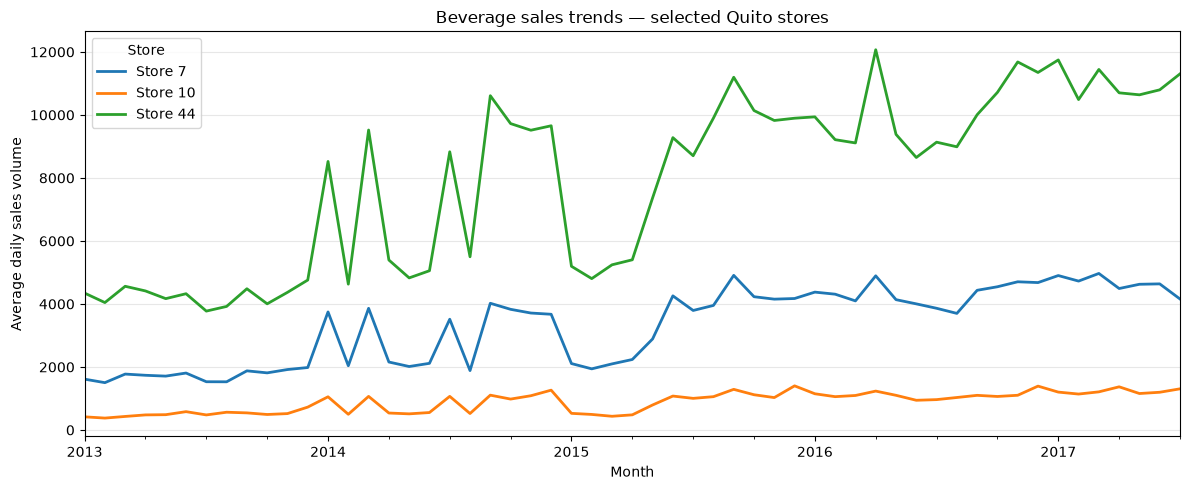

In [54]:
import matplotlib.pyplot as plt

# Select beverage sales for three illustrative stores
# Exclude August 2017 because the dataset contains only part of that month
comparison_stores = [44, 7, 10]

beverage_history = sales.loc[
    (sales["family"] == "BEVERAGES")
    & sales["store_nbr"].isin(comparison_stores)
    & (sales["date"] < "2017-08-01")
]

# Reshape the data: one row per date and one column per store
daily_comparison = beverage_history.pivot(
    index="date",
    columns="store_nbr",
    values="sales"
).sort_index()

# Calculate monthly averages using observed days, including recorded zeros
monthly_comparison = daily_comparison.resample("MS").mean()

# Use readable labels in the chart legend
monthly_comparison.columns = [
    f"Store {store_id}" for store_id in monthly_comparison.columns
]

# Plot the sales history
ax = monthly_comparison.plot(figsize=(12, 5), linewidth=2)

ax.set_title("Beverage sales trends — selected Quito stores")
ax.set_xlabel("Month")
ax.set_ylabel("Average daily sales volume")
ax.legend(title="Store")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# Load daily store transaction data
transactions = pd.read_csv(
    data_path / "transactions.csv",
    parse_dates=["date"]
)

# Inspect dataset coverage and data quality
print(f"Rows: {len(transactions):,}")
print(
    f"Date range: {transactions['date'].min().date()} — "
    f"{transactions['date'].max().date()}"
)
print(f"Stores: {transactions['store_nbr'].nunique()}")
print(f"Missing values: {transactions.isna().sum().sum():,}")

transaction_key = ["date", "store_nbr"]

print(
    "Duplicate store-date rows:",
    transactions.duplicated(subset=transaction_key).sum()
)
print(
    "Negative transactions:",
    (transactions["transactions"] < 0).sum()
)

# Check whether all transaction stores exist in the store reference
unmatched_transaction_stores = transactions.loc[
    ~transactions["store_nbr"].isin(stores["store_nbr"]),
    "store_nbr"
].unique()

print(
    "Transaction store IDs missing from reference:",
    unmatched_transaction_stores
)

transactions.head()

Rows: 83,488
Date range: 2013-01-01 — 2017-08-15
Stores: 54
Missing values: 0
Duplicate store-date rows: 0
Negative transactions: 0
Transaction store IDs missing from reference: []


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [56]:
# Aggregate sales to one row per store and date
store_day_sales = (
    sales
    .groupby(["date", "store_nbr"], as_index=False)
    .agg(total_sales=("sales", "sum"))
)

# Attach transaction counts while preserving every sales store-day
store_day_activity = store_day_sales.merge(
    transactions,
    on=["date", "store_nbr"],
    how="left",
    validate="one_to_one"
)

# Select store-days without transaction records
missing_transaction_days = store_day_activity.loc[
    store_day_activity["transactions"].isna()
]

print(f"Sales store-days: {len(store_day_activity):,}")
print(
    "Store-days without transactions:",
    f"{len(missing_transaction_days):,}"
)
print(
    "Missing transaction share:",
    f"{len(missing_transaction_days) / len(store_day_activity):.1%}"
)
print(
    "Missing transaction days with zero sales:",
    f"{(missing_transaction_days['total_sales'] == 0).sum():,}"
)
print(
    "Missing transaction days with positive sales:",
    f"{(missing_transaction_days['total_sales'] > 0).sum():,}"
)

Sales store-days: 90,936
Store-days without transactions: 7,448
Missing transaction share: 8.2%
Missing transaction days with zero sales: 7,330
Missing transaction days with positive sales: 118


In [57]:
# Load holiday and event data
holidays = pd.read_csv(
    data_path / "holidays_events.csv",
    parse_dates=["date"]
)

# Inspect table structure and data quality
print(f"Rows: {len(holidays):,}")
print(f"Columns: {holidays.shape[1]}")
print(
    f"Date range: {holidays['date'].min().date()} — "
    f"{holidays['date'].max().date()}"
)
print(f"Missing values: {holidays.isna().sum().sum():,}")
print(f"Exact duplicate rows: {holidays.duplicated().sum():,}")

# Check whether a date can contain multiple events
events_per_date = holidays.groupby("date").size()

print(
    "Dates with multiple event records:",
    f"{(events_per_date > 1).sum():,}"
)
print(
    "Maximum event records on one date:",
    events_per_date.max()
)

print("\nEvent types:")
print(holidays["type"].value_counts())

print("\nLocales:")
print(holidays["locale"].value_counts())

holidays.head(10)

Rows: 350
Columns: 6
Date range: 2012-03-02 — 2017-12-26
Missing values: 0
Exact duplicate rows: 0
Dates with multiple event records: 31
Maximum event records on one date: 4

Event types:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

Locales:
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [58]:
# Inspect event types by transfer status
transfer_summary = pd.crosstab(
    holidays["type"],
    holidays["transferred"]
)

print("Event types by transfer status:")
print(transfer_summary)

# Keep effective holidays and exclude their transferred original dates
holiday_rows = holidays.loc[
    (~holidays["transferred"])
    & holidays["type"].isin(
        ["Holiday", "Additional", "Transfer", "Bridge"]
    )
].copy()

# Keep demand-related events as a separate feature
event_rows = holidays.loc[
    (~holidays["transferred"])
    & (holidays["type"] == "Event")
].copy()

# Keep compensating working days separately
work_day_rows = holidays.loc[
    (~holidays["transferred"])
    & (holidays["type"] == "Work Day")
].copy()

print(f"\nOriginal rows: {len(holidays)}")
print(f"Transferred original dates excluded: {holidays['transferred'].sum()}")
print(f"Effective holiday rows: {len(holiday_rows)}")
print(f"Event rows: {len(event_rows)}")
print(f"Special work-day rows: {len(work_day_rows)}")

Event types by transfer status:
transferred  False  True 
type                     
Additional      51      0
Bridge           5      0
Event           56      0
Holiday        209     12
Transfer        12      0
Work Day         5      0

Original rows: 350
Transferred original dates excluded: 12
Effective holiday rows: 277
Event rows: 56
Special work-day rows: 5


In [59]:
# Create one row for every observed store-date combination
store_calendar = (
    sales[["date", "store_nbr"]]
    .drop_duplicates()
    .merge(
        stores,
        on="store_nbr",
        how="left",
        validate="many_to_one"
    )
)

def match_events_to_store_dates(calendar, event_table):
    """Return a Boolean mask matching events to applicable stores."""

    # National events apply to every store
    national_dates = event_table.loc[
        event_table["locale"] == "National",
        "date"
    ]

    national_match = calendar["date"].isin(national_dates)

    # Regional events apply when locale_name matches store state
    regional_event_pairs = pd.MultiIndex.from_frame(
        event_table.loc[
            event_table["locale"] == "Regional",
            ["date", "locale_name"]
        ].rename(columns={"locale_name": "state"})
    )

    calendar_regional_pairs = pd.MultiIndex.from_frame(
        calendar[["date", "state"]]
    )

    regional_match = pd.Series(
        calendar_regional_pairs.isin(regional_event_pairs),
        index=calendar.index
    )

    # Local events apply when locale_name matches store city
    local_event_pairs = pd.MultiIndex.from_frame(
        event_table.loc[
            event_table["locale"] == "Local",
            ["date", "locale_name"]
        ].rename(columns={"locale_name": "city"})
    )

    calendar_local_pairs = pd.MultiIndex.from_frame(
        calendar[["date", "city"]]
    )

    local_match = pd.Series(
        calendar_local_pairs.isin(local_event_pairs),
        index=calendar.index
    )

    return national_match | regional_match | local_match


# Create store-specific calendar flags
store_calendar["is_holiday"] = match_events_to_store_dates(
    store_calendar,
    holiday_rows
)

store_calendar["is_event"] = match_events_to_store_dates(
    store_calendar,
    event_rows
)

store_calendar["is_special_work_day"] = match_events_to_store_dates(
    store_calendar,
    work_day_rows
)

# Validate the resulting calendar
print(f"Store-calendar rows: {len(store_calendar):,}")
print(
    "Duplicate store-date rows:",
    store_calendar.duplicated(["date", "store_nbr"]).sum()
)
print(
    "Holiday store-days:",
    f"{store_calendar['is_holiday'].sum():,}"
)
print(
    "Event store-days:",
    f"{store_calendar['is_event'].sum():,}"
)
print(
    "Special work store-days:",
    f"{store_calendar['is_special_work_day'].sum():,}"
)

store_calendar.head()

Store-calendar rows: 90,936
Duplicate store-date rows: 0
Holiday store-days: 4,598
Event store-days: 2,970
Special work store-days: 270


,date,store_nbr,city,state,type,cluster,is_holiday,is_event,is_special_work_day
0,2013-01-01,1,Quito,Pichincha,D,13,True,False,False
1,2013-01-01,10,Quito,Pichincha,C,15,True,False,False
2,2013-01-01,11,Cayambe,Pichincha,B,6,True,False,False
3,2013-01-01,12,Latacunga,Cotopaxi,C,15,True,False,False
4,2013-01-01,13,Latacunga,Cotopaxi,C,15,True,False,False


In [60]:
# Select beverage sales for Store 44
store_44_beverages = (
    sales.loc[
        (sales["store_nbr"] == 44)
        & (sales["family"] == "BEVERAGES"),
        ["date", "sales"]
    ]
    .sort_values("date")
    .set_index("date")
)

# Validate the selected time series
print(f"Rows: {len(store_44_beverages):,}")
print(
    f"Date range: {store_44_beverages.index.min().date()} — "
    f"{store_44_beverages.index.max().date()}"
)
print(f"Duplicate dates: {store_44_beverages.index.duplicated().sum()}")

store_44_beverages.head()

Rows: 1,684
Date range: 2013-01-01 — 2017-08-15
Duplicate dates: 0


,sales
date,
2013-01-01,0.0
2013-01-02,5466.0
2013-01-03,3718.0
2013-01-04,4112.0
2013-01-05,6458.0


In [61]:
# Aggregate daily sales into monthly statistics
store_44_monthly = (
    store_44_beverages["sales"]
    .resample("MS")
    .agg(["mean", "count"])
    .rename(
        columns={
            "mean": "avg_daily_sales",
            "count": "observed_days"
        }
    )
)

store_44_monthly.head()

,avg_daily_sales,observed_days
date,,
2013-01-01,4345.290323,31
2013-02-01,4044.607143,28
2013-03-01,4561.322581,31
2013-04-01,4413.366667,30
2013-05-01,4169.064516,31


In [62]:
store_44_monthly.tail()

,avg_daily_sales,observed_days
date,,
2017-04-01,10701.800000,30
2017-05-01,10638.483871,31
2017-06-01,10796.366667,30
2017-07-01,11303.451613,31
2017-08-01,9096.866667,15


In [63]:
# Identify the last month covered by the source data
last_observed_month = store_44_beverages.index.max().to_period("M")

# Keep only months completed before the final partial month
complete_month_mask = (
    store_44_monthly.index.to_period("M")
    < last_observed_month
)

store_44_complete_months = store_44_monthly.loc[
    complete_month_mask
].copy()

# Validate the result
print(f"Last observed month: {last_observed_month}")
print(f"Complete months: {len(store_44_complete_months)}")
print(
    "Last retained month:",
    store_44_complete_months.index.max().date()
)

store_44_complete_months.tail()

Last observed month: 2017-08
Complete months: 55
Last retained month: 2017-07-01


,avg_daily_sales,observed_days
date,,
2017-03-01,11442.935484,31
2017-04-01,10701.800000,30
2017-05-01,10638.483871,31
2017-06-01,10796.366667,30
2017-07-01,11303.451613,31


In [64]:
# Aggregate sales and promotions across the entire store network
network_daily = (
    sales
    .groupby("date")
    .agg(
        total_sales=("sales", "sum"),
        promoted_items=("onpromotion", "sum")
    )
)

# Convert daily network totals into monthly averages
network_monthly = (
    network_daily
    .resample("MS")
    .agg(
        avg_daily_sales=("total_sales", "mean"),
        avg_daily_promoted_items=("promoted_items", "mean"),
        observed_days=("total_sales", "count")
    )
)

# Exclude the final incomplete month
last_observed_month = sales["date"].max().to_period("M")

network_monthly_complete = network_monthly.loc[
    network_monthly.index.to_period("M") < last_observed_month
].copy()

print(f"Complete months: {len(network_monthly_complete)}")
network_monthly_complete.tail()

Complete months: 55


,avg_daily_sales,avg_daily_promoted_items,observed_days
date,,,
2017-03-01,861419.925512,10944.870968,31
2017-04-01,863176.949652,12368.066667,30
2017-05-01,868124.104858,13375.677419,31
2017-06-01,856094.070833,13152.733333,30
2017-07-01,871337.985995,13197.677419,31


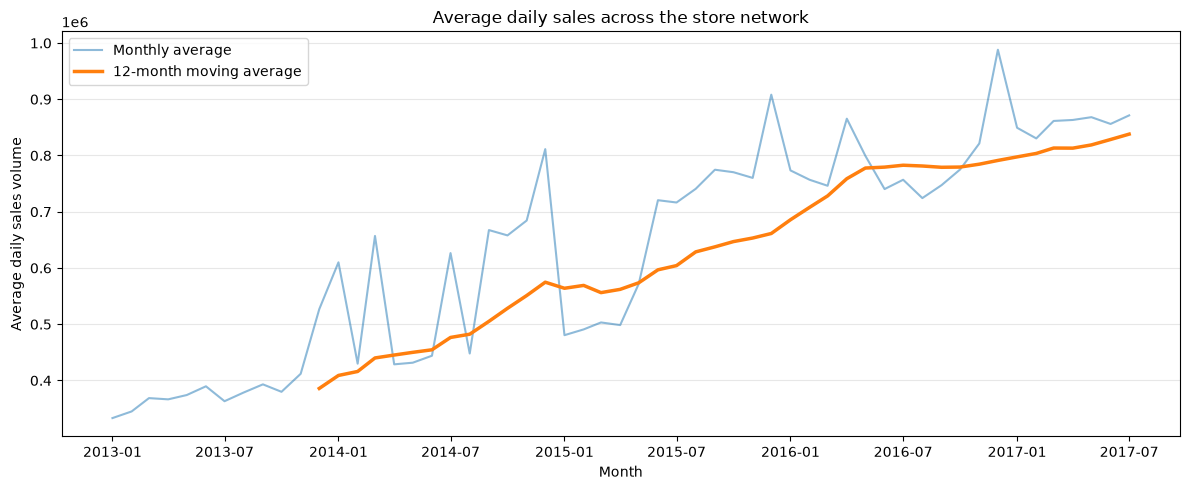

In [65]:
import matplotlib.pyplot as plt

# Keep only the metric needed for trend analysis
network_trend = network_monthly_complete[
    ["avg_daily_sales"]
].copy()

# Calculate the 12-month moving average
network_trend["moving_avg_12m"] = (
    network_trend["avg_daily_sales"]
    .rolling(window=12, min_periods=12)
    .mean()
)

# Create the chart area
fig, ax = plt.subplots(figsize=(12, 5))

# Plot actual monthly averages
ax.plot(
    network_trend.index,
    network_trend["avg_daily_sales"],
    label="Monthly average",
    linewidth=1.5,
    alpha=0.5
)

# Plot the smoothed long-term trend
ax.plot(
    network_trend.index,
    network_trend["moving_avg_12m"],
    label="12-month moving average",
    linewidth=2.5
)

# Format the chart
ax.set_title("Average daily sales across the store network")
ax.set_xlabel("Month")
ax.set_ylabel("Average daily sales volume")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
# Mark store-days with positive sales
store_activity = store_day_sales.assign(
    has_sales=store_day_sales["total_sales"] > 0
)

# Count stores with positive sales on each date
daily_store_count = (
    store_activity
    .groupby("date")
    .agg(
        stores_with_sales=("has_sales", "sum")
    )
)

# Summarize the daily store count by month
monthly_store_count = (
    daily_store_count
    .resample("MS")
    .agg(
        avg_stores_with_sales=("stores_with_sales", "mean"),
        min_stores_with_sales=("stores_with_sales", "min"),
        max_stores_with_sales=("stores_with_sales", "max")
    )
)

# Exclude the final incomplete month
monthly_store_count_complete = monthly_store_count.loc[
    monthly_store_count.index.to_period("M")
    < last_observed_month
].copy()

print("First months:")
display(monthly_store_count_complete.head())

print("Last months:")
display(monthly_store_count_complete.tail())

First months:


,avg_stores_with_sales,min_stores_with_sales,max_stores_with_sales
date,,,
2013-01-01,44.548387,1,46
2013-02-01,46.000000,46,46
2013-03-01,46.000000,46,46
2013-04-01,46.000000,46,46
2013-05-01,46.741935,46,47


Last months:


,avg_stores_with_sales,min_stores_with_sales,max_stores_with_sales
date,,,
2017-03-01,53.000000,53,53
2017-04-01,53.366667,53,54
2017-05-01,54.000000,54,54
2017-06-01,54.000000,54,54
2017-07-01,54.000000,54,54


In [67]:
# Aggregate sales and selling store-days by month
monthly_normalized_sales = (
    store_activity
    .set_index("date")
    .resample("MS")
    .agg(
        total_sales=("total_sales", "sum"),
        selling_store_days=("has_sales", "sum")
    )
)

# Calculate sales per selling store-day
monthly_normalized_sales["avg_sales_per_selling_store_day"] = (
    monthly_normalized_sales["total_sales"]
    / monthly_normalized_sales["selling_store_days"]
)

# Exclude the final incomplete month
monthly_normalized_sales_complete = monthly_normalized_sales.loc[
    monthly_normalized_sales.index.to_period("M")
    < last_observed_month
].copy()

# Display the beginning and end of the period
print("First months:")
display(
    monthly_normalized_sales_complete[
        ["selling_store_days", "avg_sales_per_selling_store_day"]
    ].head()
)

print("Last months:")
display(
    monthly_normalized_sales_complete[
        ["selling_store_days", "avg_sales_per_selling_store_day"]
    ].tail()
)

First months:


,selling_store_days,avg_sales_per_selling_store_day
date,,
2013-01-01,1381,7478.366935
2013-02-01,1288,7499.192374
2013-03-01,1426,8014.373799
2013-04-01,1380,7966.278796
2013-05-01,1449,8003.936513


Last months:


,selling_store_days,avg_sales_per_selling_store_day
date,,
2017-03-01,1643,16253.206142
2017-04-01,1601,16174.458769
2017-05-01,1674,16076.372312
2017-06-01,1620,15853.593904
2017-07-01,1674,16135.888630


In [68]:
# Keep only complete calendar years
complete_year_data = monthly_normalized_sales_complete.loc[
    monthly_normalized_sales_complete.index.year < 2017
].copy()

# Add the calendar year as a separate column
complete_year_data["year"] = complete_year_data.index.year

# Aggregate monthly totals into annual totals
annual_summary = (
    complete_year_data
    .groupby("year")
    .agg(
        total_sales=("total_sales", "sum"),
        selling_store_days=("selling_store_days", "sum")
    )
)

# Calculate the weighted annual average per selling store-day
annual_summary["avg_sales_per_selling_store_day"] = (
    annual_summary["total_sales"]
    / annual_summary["selling_store_days"]
)

# Calculate growth relative to the previous year
annual_summary["year_over_year_growth_pct"] = (
    annual_summary["avg_sales_per_selling_store_day"]
    .pct_change()
    .mul(100)
)

annual_summary.round(1)

,total_sales,selling_store_days,avg_sales_per_selling_store_day,year_over_year_growth_pct
year,,,,
2013,140419013.9,16912,8302.9,NaN
2014,209474246.3,17140,12221.4,47.2
2015,240880100.7,18346,13129.8,7.4
2016,288654523.0,19111,15104.1,15.0


In [69]:
# Keep store-day records from complete calendar years
seasonality_data = store_activity.loc[
    store_activity["date"].dt.year.between(2013, 2016)
].copy()

# Extract the calendar month from each date
seasonality_data["month"] = seasonality_data["date"].dt.month

# Aggregate sales and selling store-days by calendar month
monthly_seasonality = (
    seasonality_data
    .groupby("month")
    .agg(
        total_sales=("total_sales", "sum"),
        selling_store_days=("has_sales", "sum")
    )
)

# Calculate average sales per selling store-day for each month
monthly_seasonality["avg_sales_per_selling_store_day"] = (
    monthly_seasonality["total_sales"]
    / monthly_seasonality["selling_store_days"]
)

# Calculate the overall benchmark for all complete years
overall_average = (
    seasonality_data["total_sales"].sum()
    / seasonality_data["has_sales"].sum()
)

# Compare every month with the overall average
monthly_seasonality["difference_vs_overall_pct"] = (
    (
        monthly_seasonality["avg_sales_per_selling_store_day"]
        / overall_average
        - 1
    )
    * 100
)

# Add readable month names
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_seasonality["month_name"] = (
    monthly_seasonality.index.map(month_names)
)

monthly_seasonality[
    [
        "month_name",
        "avg_sales_per_selling_store_day",
        "difference_vs_overall_pct"
    ]
].round(1)

,month_name,avg_sales_per_selling_store_day,difference_vs_overall_pct
month,,,
1,Jan,11693.4,-4.9
2,Feb,10432.1,-15.2
3,Mar,11651.2,-5.3
4,Apr,11104.5,-9.7
5,May,11167.8,-9.2
6,Jun,11647.0,-5.3
7,Jul,12518.7,1.8
8,Aug,11598.2,-5.7
9,Sep,13064.7,6.2


In [70]:
# Add year and month columns without modifying the original table
seasonality_by_year = seasonality_data.assign(
    year=seasonality_data["date"].dt.year,
    month=seasonality_data["date"].dt.month
)

# Aggregate sales separately for each year and month
seasonality_by_year = (
    seasonality_by_year
    .groupby(["year", "month"])
    .agg(
        total_sales=("total_sales", "sum"),
        selling_store_days=("has_sales", "sum")
    )
)

# Calculate sales per selling store-day
seasonality_by_year["avg_sales_per_store_day"] = (
    seasonality_by_year["total_sales"]
    / seasonality_by_year["selling_store_days"]
)

# Reshape years into separate columns
seasonality_pivot = (
    seasonality_by_year["avg_sales_per_store_day"]
    .unstack("year")
)

# Replace month numbers with readable names
seasonality_pivot.index = seasonality_pivot.index.map(month_names)

seasonality_pivot.round(0)

year,2013,2014,2015,2016
month,,,,
Jan,7478.0,13394.0,10338.0,15071.0
Feb,7499.0,9148.0,10105.0,14279.0
Mar,8014.0,13978.0,10202.0,14096.0
Apr,7966.0,9233.0,10174.0,16329.0
May,8004.0,9363.0,11649.0,15082.0
Jun,8290.0,9447.0,14410.0,13968.0
Jul,7850.0,13257.0,14264.0,14280.0
Aug,8056.0,9510.0,14424.0,13894.0
Sep,8364.0,14002.0,14898.0,14652.0


In [71]:
# Convert the grouped table back to regular columns
seasonality_index = (
    seasonality_by_year[
        ["avg_sales_per_store_day"]
    ]
    .reset_index()
)

# Add the annual average to every month
seasonality_index["annual_average"] = (
    seasonality_index["year"].map(
        annual_summary["avg_sales_per_selling_store_day"]
    )
)

# Calculate each month as a percentage of its annual average
seasonality_index["seasonal_index"] = (
    seasonality_index["avg_sales_per_store_day"]
    / seasonality_index["annual_average"]
    * 100
)

# Reshape the result into a year-by-month table
seasonal_index_pivot = seasonality_index.pivot(
    index="month",
    columns="year",
    values="seasonal_index"
)

# Replace month numbers with readable names
seasonal_index_pivot.index = seasonal_index_pivot.index.map(
    month_names
)

seasonal_index_pivot.round(1)

year,2013,2014,2015,2016
month,,,,
Jan,90.1,109.6,78.7,99.8
Feb,90.3,74.8,77.0,94.5
Mar,96.5,114.4,77.7,93.3
Apr,95.9,75.5,77.5,108.1
May,96.4,76.6,88.7,99.9
Jun,99.8,77.3,109.8,92.5
Jul,94.5,108.5,108.6,94.5
Aug,97.0,77.8,109.9,92.0
Sep,100.7,114.6,113.5,97.0


In [72]:
# Summarize seasonal consistency across years
seasonal_profile = pd.DataFrame({
    "avg_seasonal_index": seasonal_index_pivot.mean(axis=1),
    "min_index": seasonal_index_pivot.min(axis=1),
    "max_index": seasonal_index_pivot.max(axis=1),
    "index_std_dev": seasonal_index_pivot.std(axis=1),
    "years_above_100": (seasonal_index_pivot > 100).sum(axis=1)
})

seasonal_profile.round(1)

,avg_seasonal_index,min_index,max_index,index_std_dev,years_above_100
month,,,,,
Jan,94.5,78.7,109.6,13.2,1
Feb,84.2,74.8,94.5,9.7,0
Mar,95.5,77.7,114.4,15.0,1
Apr,89.3,75.5,108.1,15.6,1
May,90.4,76.6,99.9,10.3,0
Jun,94.8,77.3,109.8,13.7,1
Jul,101.6,94.5,108.6,8.1,2
Aug,94.2,77.8,109.9,13.2,1
Sep,106.4,97.0,114.6,8.9,3


In [73]:
# Keep only complete years and required columns
family_sales = sales.loc[
    sales["date"].dt.year.between(2013, 2016),
    ["date", "family", "sales"]
].copy()

# Calculate total network sales for each family and day
daily_family_sales = (
    family_sales
    .groupby(["date", "family"], as_index=False)
    .agg(daily_sales=("sales", "sum"))
)

# Add year and month for further comparisons
daily_family_sales["year"] = daily_family_sales["date"].dt.year
daily_family_sales["month"] = daily_family_sales["date"].dt.month

print(f"Rows before aggregation: {len(family_sales):,}")
print(f"Rows after aggregation: {len(daily_family_sales):,}")

daily_family_sales.head()

Rows before aggregation: 2,596,374
Rows after aggregation: 48,081


,date,family,daily_sales,year,month
0,2013-01-01,AUTOMOTIVE,0.0,2013,1
1,2013-01-01,BABY CARE,0.0,2013,1
2,2013-01-01,BEAUTY,2.0,2013,1
3,2013-01-01,BEVERAGES,810.0,2013,1
4,2013-01-01,BOOKS,0.0,2013,1


In [74]:
# Calculate average daily sales for each family, year, and month
monthly_family_sales = (
    daily_family_sales
    .groupby(["family", "year", "month"], as_index=False)
    .agg(avg_monthly_daily_sales=("daily_sales", "mean"))
)

# Calculate average daily sales for each family and year
annual_family_sales = (
    daily_family_sales
    .groupby(["family", "year"], as_index=False)
    .agg(avg_annual_daily_sales=("daily_sales", "mean"))
)

# Add the annual average to every monthly row
family_seasonality = monthly_family_sales.merge(
    annual_family_sales,
    on=["family", "year"],
    how="left",
    validate="many_to_one"
)

# Compare each month with the annual average
family_seasonality["seasonal_index"] = (
    family_seasonality["avg_monthly_daily_sales"]
    / family_seasonality["avg_annual_daily_sales"]
    * 100
)

# Inspect one example
family_seasonality.loc[
    family_seasonality["family"] == "BEVERAGES"
].round(1)

,family,year,month,avg_monthly_daily_sales,avg_annual_daily_sales,seasonal_index
144,BEVERAGES,2013,1,53892.0,59829.3,90.1
145,BEVERAGES,2013,2,53866.2,59829.3,90.0
146,BEVERAGES,2013,3,58781.3,59829.3,98.2
147,BEVERAGES,2013,4,58104.0,59829.3,97.1
148,BEVERAGES,2013,5,58842.7,59829.3,98.4
149,BEVERAGES,2013,6,60970.2,59829.3,101.9
150,BEVERAGES,2013,7,53692.4,59829.3,89.7
151,BEVERAGES,2013,8,58417.0,59829.3,97.6
152,BEVERAGES,2013,9,63605.1,59829.3,106.3
153,BEVERAGES,2013,10,59850.2,59829.3,100.0


In [75]:
# Keep only December observations
december_data = family_seasonality.loc[
    family_seasonality["month"] == 12
].copy()

# Mark years when December was above the annual average
december_data["above_annual_average"] = (
    december_data["seasonal_index"] > 100
)

# Summarize the December pattern for every family
december_profile = (
    december_data
    .groupby("family", as_index=False)
    .agg(
        avg_december_index=("seasonal_index", "mean"),
        min_december_index=("seasonal_index", "min"),
        max_december_index=("seasonal_index", "max"),
        index_std_dev=("seasonal_index", "std"),
        years_above_100=("above_annual_average", "sum"),
        avg_december_daily_sales=("avg_monthly_daily_sales", "mean")
    )
    .sort_values(
        ["years_above_100", "avg_december_index"],
        ascending=[False, False]
    )
)

december_profile.head(15).round(1)

,family,avg_december_index,min_december_index,max_december_index,index_std_dev,years_above_100,avg_december_daily_sales
11,FROZEN FOODS,400.7,367.4,423.2,24.1,4,34243.7
22,"LIQUOR,WINE,BEER",197.7,184.0,211.3,11.1,4,8959.7
13,GROCERY II,167.8,160.0,181.0,9.5,4,1896.9
30,PRODUCE,162.6,112.1,192.1,35.8,4,97360.2
20,LAWN AND GARDEN,150.8,103.7,266.1,77.2,4,387.7
12,GROCERY I,134.7,133.0,137.9,2.2,4,264388.5
3,BEVERAGES,131.3,119.5,143.4,10.9,4,155353.2
8,DAIRY,130.7,110.7,182.1,34.3,4,45030.8
28,POULTRY,129.2,107.8,184.5,36.9,4,22814.5
2,BEAUTY,127.8,106.8,145.9,18.7,4,237.4


In [76]:
# Calculate average December sales for every family and year
december_average = (
    daily_family_sales.loc[daily_family_sales["month"] == 12]
    .groupby(["family", "year"], as_index=False)
    .agg(december_avg_daily_sales=("daily_sales", "mean"))
)

# Calculate the January-November baseline
regular_month_average = (
    daily_family_sales.loc[daily_family_sales["month"] != 12]
    .groupby(["family", "year"], as_index=False)
    .agg(regular_avg_daily_sales=("daily_sales", "mean"))
)

# Combine December sales with the regular-month baseline
december_impact_by_year = december_average.merge(
    regular_month_average,
    on=["family", "year"],
    how="left",
    validate="one_to_one"
)

# Calculate additional daily sales in December
december_impact_by_year["excess_daily_sales"] = (
    december_impact_by_year["december_avg_daily_sales"]
    - december_impact_by_year["regular_avg_daily_sales"]
)

# Calculate the percentage uplift
december_impact_by_year["uplift_pct"] = (
    december_impact_by_year["excess_daily_sales"]
    / december_impact_by_year["regular_avg_daily_sales"]
    * 100
)

# Mark years with a positive December increase
december_impact_by_year["has_increase"] = (
    december_impact_by_year["excess_daily_sales"] > 0
)

# Summarize all four years for every family
december_contribution = (
    december_impact_by_year
    .groupby("family", as_index=False)
    .agg(
        avg_regular_daily_sales=("regular_avg_daily_sales", "mean"),
        avg_december_daily_sales=("december_avg_daily_sales", "mean"),
        avg_excess_daily_sales=("excess_daily_sales", "mean"),
        avg_uplift_pct=("uplift_pct", "mean"),
        years_with_increase=("has_increase", "sum")
    )
)

# Calculate each family's share of the positive December uplift
total_positive_excess = (
    december_contribution["avg_excess_daily_sales"]
    .clip(lower=0)
    .sum()
)

december_contribution["share_of_positive_uplift_pct"] = (
    december_contribution["avg_excess_daily_sales"].clip(lower=0)
    / total_positive_excess
    * 100
)

# Show the largest contributors
december_contribution = december_contribution.sort_values(
    "avg_excess_daily_sales",
    ascending=False
)

december_contribution.head(15).round(1)

,family,avg_regular_daily_sales,avg_december_daily_sales,avg_excess_daily_sales,avg_uplift_pct,years_with_increase,share_of_positive_uplift_pct
12,GROCERY I,190394.0,264388.5,73994.5,39.0,4,33.1
3,BEVERAGES,115414.1,155353.2,39939.1,35.2,4,17.9
30,PRODUCE,61097.4,97360.2,36262.8,73.4,4,16.2
11,FROZEN FOODS,6219.2,34243.7,28024.6,449.9,4,12.5
7,CLEANING,55336.3,66935.2,11598.9,21.2,4,5.2
8,DAIRY,35615.6,45030.8,9415.2,35.4,4,4.2
22,"LIQUOR,WINE,BEER",4156.4,8959.7,4803.3,116.9,4,2.1
28,POULTRY,18190.8,22814.5,4623.7,33.9,4,2.1
18,HOME CARE,8099.5,11861.8,3762.4,57.0,3,1.7
25,PERSONAL CARE,13850.5,17012.0,3161.4,24.2,4,1.4


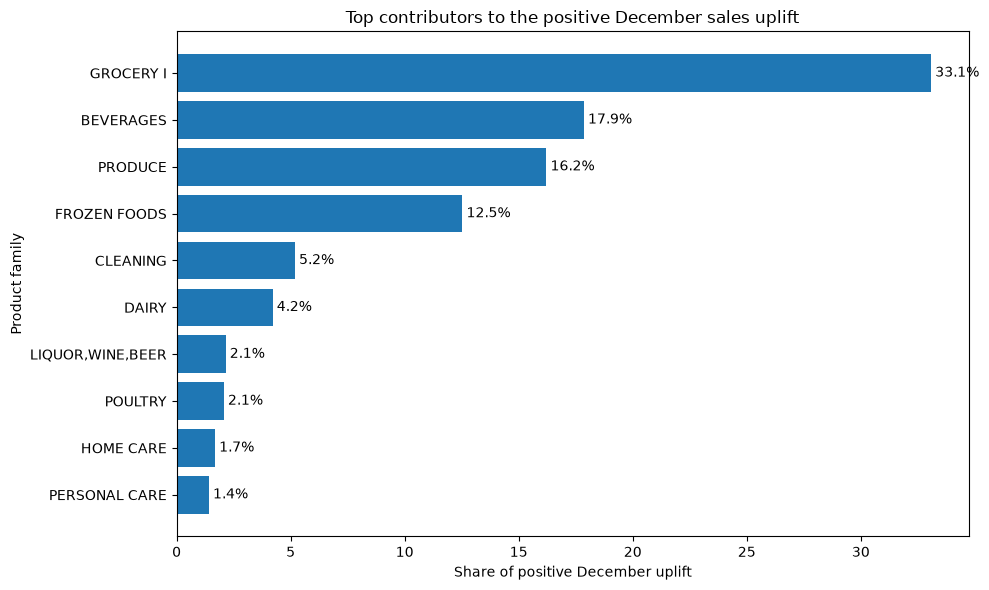

In [77]:
# Select the ten largest December contributors
top_december_contributors = (
    december_contribution
    .head(10)
    .sort_values("share_of_positive_uplift_pct")
)

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_december_contributors["family"],
    top_december_contributors["share_of_positive_uplift_pct"]
)

# Add percentage labels
ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3
)

ax.set_title("Top contributors to the positive December sales uplift")
ax.set_xlabel("Share of positive December uplift")
ax.set_ylabel("Product family")

plt.tight_layout()
plt.show()

In [78]:
# Select only the required columns
promotion_data = sales[["sales", "onpromotion"]].copy()

# Mark rows that contain at least one promoted item
promotion_data["is_promoted"] = (
    promotion_data["onpromotion"] > 0
)

# Mark rows with zero sales
promotion_data["is_zero_sales"] = (
    promotion_data["sales"] == 0
)

# Compare promoted and non-promoted observations
promotion_summary = (
    promotion_data
    .groupby("is_promoted")
    .agg(
        row_count=("sales", "size"),
        avg_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        zero_sales_pct=("is_zero_sales", "mean"),
        avg_promoted_items=("onpromotion", "mean")
    )
)

# Convert proportions to percentages
promotion_summary["row_share_pct"] = (
    promotion_summary["row_count"]
    / promotion_summary["row_count"].sum()
    * 100
)

promotion_summary["zero_sales_pct"] *= 100

# Replace Boolean labels with readable names
promotion_summary = promotion_summary.rename(
    index={
        False: "Not promoted",
        True: "Promoted"
    }
)

promotion_summary.round(1)

,row_count,avg_sales,median_sales,zero_sales_pct,avg_promoted_items,row_share_pct
is_promoted,,,,,,
Not promoted,2389559,158.2,3.0,39.3,0.0,79.6
Promoted,611329,1137.7,373.0,0.0,12.8,20.4


In [79]:
# Add store and family columns to the promotion dataset
promotion_data["store_nbr"] = sales["store_nbr"]
promotion_data["family"] = sales["family"]

# Calculate sales for each store, family, and promotion status
store_family_promotion_summary = (
    promotion_data
    .groupby(
        ["store_nbr", "family", "is_promoted"],
        as_index=False
    )
    .agg(
        avg_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        observation_count=("sales", "size")
    )
)

print(
    f"Store-family-status combinations: "
    f"{len(store_family_promotion_summary):,}"
)

store_family_promotion_summary.head(10)

Store-family-status combinations: 3,382


,store_nbr,family,is_promoted,avg_sales,median_sales,observation_count
0,1,AUTOMOTIVE,False,3.238922,3.0000,1670
1,1,AUTOMOTIVE,True,4.714286,5.0000,14
2,1,BABY CARE,False,0.000000,0.0000,1684
3,1,BEAUTY,False,2.143345,2.0000,1465
4,1,BEAUTY,True,4.182648,4.0000,219
5,1,BEVERAGES,False,1042.553383,974.0000,665
6,1,BEVERAGES,True,1943.543670,2097.0000,1019
7,1,BOOKS,False,0.125297,0.0000,1684
8,1,BREAD/BAKERY,False,306.151878,318.8375,926
9,1,BREAD/BAKERY,True,377.962492,405.7250,758


In [80]:
# Put average sales without and with promotion into separate columns
avg_sales_comparison = (
    store_family_promotion_summary
    .pivot(
        index=["store_nbr", "family"],
        columns="is_promoted",
        values="avg_sales"
    )
    .rename(
        columns={
            False: "avg_sales_no_promo",
            True: "avg_sales_promo"
        }
    )
)

# Put observation counts into separate columns
observation_comparison = (
    store_family_promotion_summary
    .pivot(
        index=["store_nbr", "family"],
        columns="is_promoted",
        values="observation_count"
    )
    .rename(
        columns={
            False: "days_no_promo",
            True: "days_promo"
        }
    )
)

# Combine sales averages and observation counts
store_family_comparison = (
    avg_sales_comparison
    .join(observation_comparison)
    .dropna()
    .reset_index()
)

# Keep combinations with enough observations
reliable_comparisons = store_family_comparison.loc[
    (store_family_comparison["days_no_promo"] >= 30)
    & (store_family_comparison["days_promo"] >= 30)
    & (store_family_comparison["avg_sales_no_promo"] > 0)
].copy()

# Calculate the promotion uplift
reliable_comparisons["sales_ratio"] = (
    reliable_comparisons["avg_sales_promo"]
    / reliable_comparisons["avg_sales_no_promo"]
)

reliable_comparisons["uplift_pct"] = (
    (reliable_comparisons["sales_ratio"] - 1) * 100
)

print(
    f"Comparable store-family combinations: "
    f"{len(reliable_comparisons):,}"
)

reliable_comparisons.head(10).round(1)

Comparable store-family combinations: 1,295


is_promoted,store_nbr,family,avg_sales_no_promo,avg_sales_promo,days_no_promo,days_promo,sales_ratio,uplift_pct
1,1,BEAUTY,2.1,4.2,1465.0,219.0,2.0,95.1
2,1,BEVERAGES,1042.6,1943.5,665.0,1019.0,1.9,86.4
3,1,BREAD/BAKERY,306.2,378.0,926.0,758.0,1.2,23.5
4,1,CELEBRATION,9.6,19.3,1627.0,57.0,2.0,100.4
5,1,CLEANING,611.1,662.2,717.0,967.0,1.1,8.4
6,1,DAIRY,517.3,709.8,732.0,952.0,1.4,37.2
7,1,DELI,112.3,137.3,968.0,716.0,1.2,22.3
8,1,EGGS,138.4,145.4,1189.0,495.0,1.1,5.1
9,1,FROZEN FOODS,120.7,140.5,944.0,740.0,1.2,16.4
10,1,GROCERY I,1873.2,2404.2,574.0,1110.0,1.3,28.3


In [81]:
# Mark store-family combinations with positive promotion uplift
reliable_comparisons["has_positive_uplift"] = (
    reliable_comparisons["uplift_pct"] > 0
)

# Create an overall promotion effect summary
overall_promotion_effect = pd.Series(
    {
        "comparable_combinations": len(reliable_comparisons),
        "positive_uplift_share_pct": (
            reliable_comparisons["has_positive_uplift"].mean() * 100
        ),
        "median_uplift_pct": (
            reliable_comparisons["uplift_pct"].median()
        ),
        "lower_quartile_uplift_pct": (
            reliable_comparisons["uplift_pct"].quantile(0.25)
        ),
        "upper_quartile_uplift_pct": (
            reliable_comparisons["uplift_pct"].quantile(0.75)
        ),
        "median_sales_ratio": (
            reliable_comparisons["sales_ratio"].median()
        )
    },
    name="value"
)

overall_promotion_effect.round(1)

comparable_combinations      1295.0
positive_uplift_share_pct      95.2
median_uplift_pct              57.7
lower_quartile_uplift_pct      23.2
upper_quartile_uplift_pct     150.1
median_sales_ratio              1.6
Name: value, dtype: float64

In [82]:
# Summarize promotion effects by product family
family_promotion_effect = (
    reliable_comparisons
    .groupby("family", as_index=False)
    .agg(
        stores_compared=("store_nbr", "nunique"),
        median_sales_no_promo=("avg_sales_no_promo", "median"),
        median_sales_promo=("avg_sales_promo", "median"),
        median_uplift_pct=("uplift_pct", "median"),
        positive_store_share_pct=("has_positive_uplift", "mean")
    )
)

# Convert the share from a proportion to a percentage
family_promotion_effect["positive_store_share_pct"] *= 100

# Keep families represented by at least 20 stores
reliable_family_effect = (
    family_promotion_effect.loc[
        family_promotion_effect["stores_compared"] >= 20
    ]
    .sort_values("median_uplift_pct", ascending=False)
)

reliable_family_effect.head(15).round(1)

,family,stores_compared,median_sales_no_promo,median_sales_promo,median_uplift_pct,positive_store_share_pct
28,SCHOOL AND OFFICE SUPPLIES,41,0.6,17.3,2909.0,100.0
27,PRODUCE,54,497.4,1683.8,188.2,100.0
14,HOME AND KITCHEN II,54,9.6,27.0,171.1,100.0
15,HOME CARE,54,101.2,246.2,169.3,100.0
23,PET SUPPLIES,31,4.3,10.3,130.4,100.0
13,HOME AND KITCHEN I,54,13.6,33.2,114.0,98.1
1,BEAUTY,54,2.1,5.1,107.5,100.0
2,BEVERAGES,54,1114.1,2612.6,104.4,100.0
4,CELEBRATION,34,8.8,16.3,90.3,100.0
9,FROZEN FOODS,54,72.9,159.1,72.7,100.0


In [83]:
# Calculate the sales difference for every store-family combination
reliable_comparisons["absolute_sales_increase"] = (
    reliable_comparisons["avg_sales_promo"]
    - reliable_comparisons["avg_sales_no_promo"]
)

# Summarize the promotion effect by family
family_promotion_impact = (
    reliable_comparisons
    .groupby("family", as_index=False)
    .agg(
        stores_compared=("store_nbr", "nunique"),
        median_sales_no_promo=("avg_sales_no_promo", "median"),
        median_sales_promo=("avg_sales_promo", "median"),
        median_absolute_increase=(
            "absolute_sales_increase",
            "median"
        ),
        median_uplift_pct=("uplift_pct", "median"),
        positive_store_share_pct=("has_positive_uplift", "mean")
    )
)

# Convert the proportion to a percentage
family_promotion_impact["positive_store_share_pct"] *= 100

# Keep sufficiently represented families
family_promotion_impact = (
    family_promotion_impact.loc[
        family_promotion_impact["stores_compared"] >= 20
    ]
    .sort_values(
        "median_absolute_increase",
        ascending=False
    )
)

family_promotion_impact.head(15).round(1)

,family,stores_compared,median_sales_no_promo,median_sales_promo,median_absolute_increase,median_uplift_pct,positive_store_share_pct
2,BEVERAGES,54,1114.1,2612.6,1439.9,104.4,100.0
27,PRODUCE,54,497.4,1683.8,1142.9,188.2,100.0
10,GROCERY I,54,2698.8,3746.3,1051.4,28.8,98.1
6,DAIRY,54,408.3,687.4,248.8,46.5,100.0
5,CLEANING,54,902.9,1082.3,163.1,15.1,92.6
15,HOME CARE,54,101.2,246.2,162.0,169.3,100.0
3,BREAD/BAKERY,54,360.8,510.6,99.4,23.5,90.7
22,PERSONAL CARE,54,210.1,288.7,68.0,26.5,92.6
21,MEATS,54,237.1,285.7,65.2,22.9,88.9
25,POULTRY,54,179.7,245.1,62.5,25.1,96.3


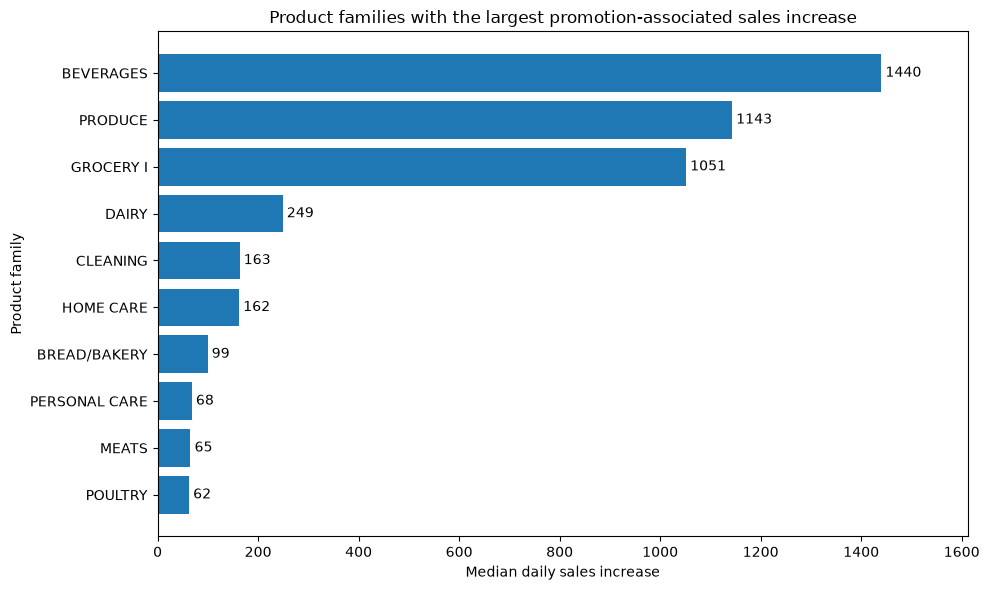

In [84]:
# Select the ten families with the largest absolute increase
top_promotion_families = (
    family_promotion_impact
    .head(10)
    .sort_values("median_absolute_increase")
)

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_promotion_families["family"],
    top_promotion_families["median_absolute_increase"]
)

# Add value labels
ax.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

# Add space for labels
ax.set_xlim(
    0,
    top_promotion_families["median_absolute_increase"].max() * 1.12
)

ax.set_title("Product families with the largest promotion-associated sales increase")
ax.set_xlabel("Median daily sales increase")
ax.set_ylabel("Product family")

plt.tight_layout()
plt.show()